#TASK 4 — SALES PREDICTION USING PYTHON

##Markdown Title

## Sales Prediction using Python

#### CodeAlpha Data Science Internship — Task 4

### Objective

The objective of this project is to predict sales based on different
advertising channels and identify how advertising expenditure influences
sales performance.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Project Components

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Advertising Analysis
- Feature Selection
- Regression Modeling
- Model Evaluation
- Sales Prediction
- Business Insights

##Markdown Introduction

## Introduction

Sales prediction is an important application of data science that helps
businesses estimate future sales based on historical information.

Advertising expenditure across different platforms can have a significant
relationship with sales performance. In this project, Python is used to
analyze advertising data, identify relationships between advertising
channels and sales, and develop machine learning models for predicting
sales.

The project follows a complete data science workflow, including data
cleaning, exploratory data analysis, visualization, feature selection,
model training, and evaluation.

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


##Uploading Data Set

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


##Loading Data Set

In [ ]:
import os

filename = list(uploaded.keys())[0]

if filename.endswith(".csv"):
    df = pd.read_csv(filename)

elif filename.endswith(".xlsx"):
    df = pd.read_excel(filename)

elif filename.endswith(".xls"):
    df = pd.read_excel(filename)

else:
    raise ValueError("Unsupported file format")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


##Data Set Shape

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 200
Number of Columns: 5


##Column Names

In [ ]:
print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

Unnamed: 0
TV
Radio
Newspaper
Sales


##First Five Rows

In [ ]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


##Last Five Rows

In [ ]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


##Data Set Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


##Statistical Summary

In [ ]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


#DATA CLEANING

##Cleaning Column Nmaes

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Cleaned Columns:")
print(df.columns.tolist())

Cleaned Columns:
['unnamed:_0', 'tv', 'radio', 'newspaper', 'sales']


##Missing Values

In [ ]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
unnamed:_0,0,0.0
tv,0,0.0
radio,0,0.0
newspaper,0,0.0
sales,0,0.0


##Duplicates

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


##Removing Duplicates

In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (200, 5)


##Converting Numeric Columns

In [ ]:
for column in df.columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df.dtypes)

unnamed:_0      int64
tv            float64
radio         float64
newspaper     float64
sales         float64
dtype: object


##Handling Missing Values

In [ ]:
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
unnamed:_0    0
tv            0
radio         0
newspaper     0
sales         0
dtype: int64


#EXPLORATORY DATA ANALYSIS

##Data Set Summary

In [ ]:
print("========== DATASET SUMMARY ==========")

print("Total Records:", len(df))
print("Total Features:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\n======================================")

========== DATASET SUMMARY ==========
Total Records: 200
Total Features: 5

Columns:
['unnamed:_0', 'tv', 'radio', 'newspaper', 'sales']



##Sales Distribution

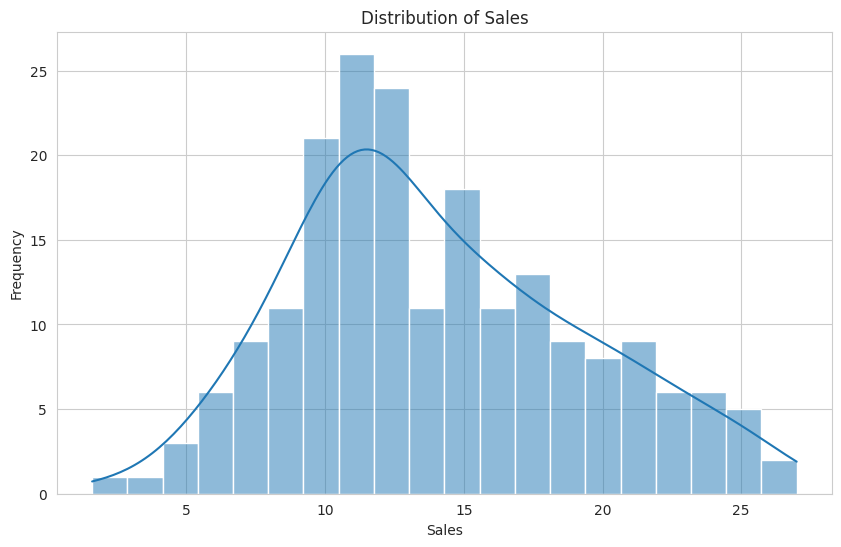

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["sales"],
    bins=20,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

##Sales Box PLot

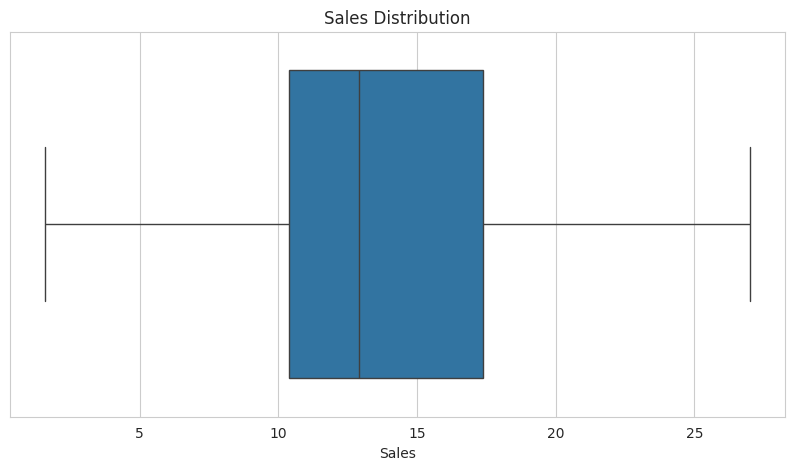

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["sales"]
)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.show()

#ADVERTISING ANALYSIS

##TV Advertising VS Sales

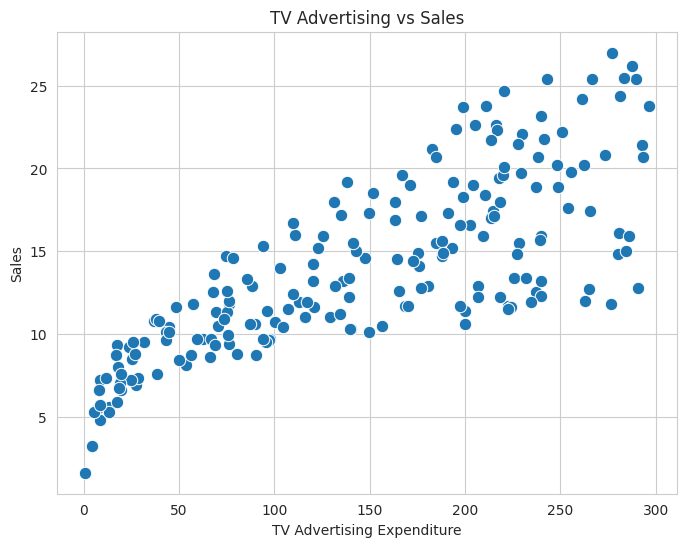

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="tv",
    y="sales",
    s=80
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Sales")

plt.show()

##Radio Advertising VS Sales

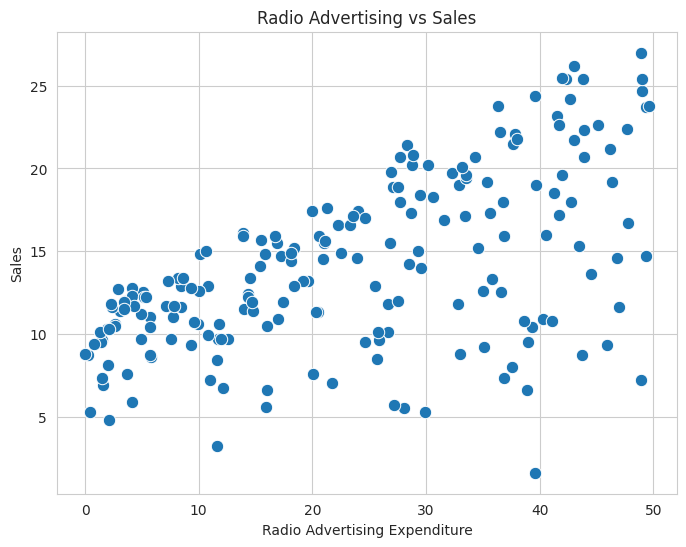

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="radio",
    y="sales",
    s=80
)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Expenditure")
plt.ylabel("Sales")

plt.show()

##Newspaper Advertising VS Sales

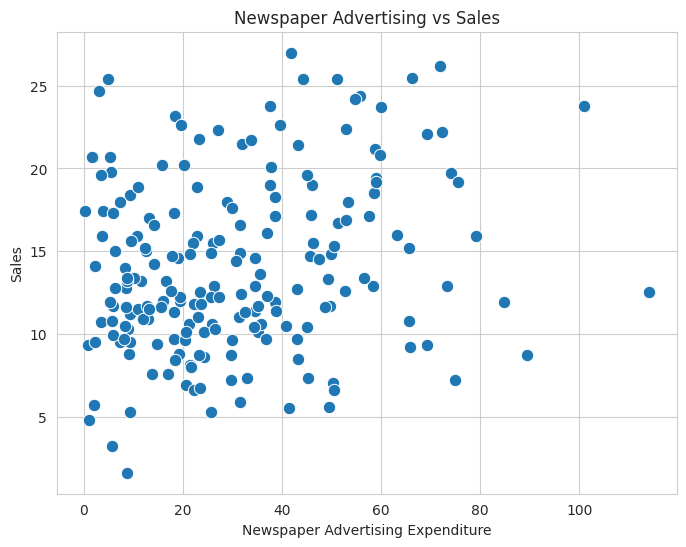

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="newspaper",
    y="sales",
    s=80
)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Expenditure")
plt.ylabel("Sales")

plt.show()

#Correlation Analysis

In [ ]:
correlation_matrix = df.corr()

correlation_matrix

,unnamed:_0,tv,radio,newspaper,sales
unnamed:_0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
tv,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


##Correlation Heatmap

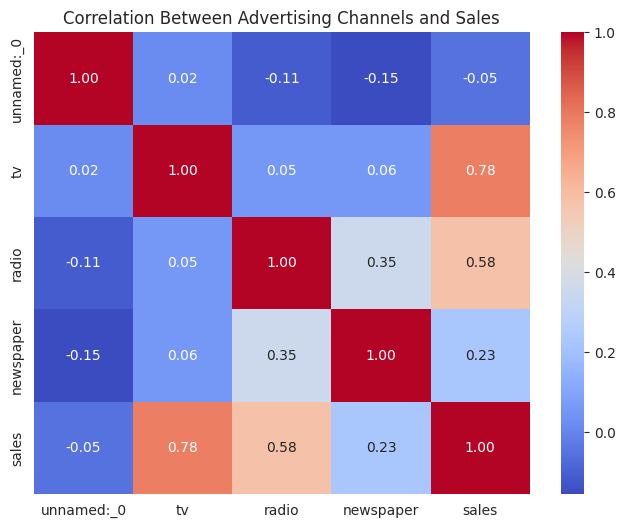

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Advertising Channels and Sales")

plt.show()

##Correlation With Sales

In [ ]:
sales_correlation = (
    df.corr()["sales"]
    .sort_values(ascending=False)
)

print("Correlation with Sales:")
print(sales_correlation)

Correlation with Sales:
sales         1.000000
tv            0.782224
radio         0.576223
newspaper     0.228299
unnamed:_0   -0.051616
Name: sales, dtype: float64


##Advertising Spending Summary

In [ ]:
advertising_columns = [
    column for column in ["tv", "radio", "newspaper"]
    if column in df.columns
]

df[advertising_columns].describe()

,tv,radio,newspaper
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000
std,85.854236,14.846809,21.778621
min,0.700000,0.000000,0.300000
25%,74.375000,9.975000,12.750000
50%,149.750000,22.900000,25.750000
75%,218.825000,36.525000,45.100000
max,296.400000,49.600000,114.000000


##Feature Seletion

In [ ]:
features = [
    column for column in ["tv", "radio", "newspaper"]
    if column in df.columns
]

X = df[features]
y = df["sales"]

print("Selected Features:")
print(features)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Selected Features:
['tv', 'radio', 'newspaper']

Feature Shape: (200, 3)
Target Shape: (200,)


##Train Test Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 160
Testing Samples: 40


We're using 80% training data and 20% testing data.

#MODEL 1 - Linear Regression

In [ ]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


##Linear Regression Predictions

In [ ]:
y_pred_linear = linear_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


##Linear Regression Evaluation

In [ ]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("===== Linear Regression Results =====")

print(f"MAE  : {mae_linear:.4f}")
print(f"MSE  : {mse_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

===== Linear Regression Results =====
MAE  : 1.4608
MSE  : 3.1741
RMSE : 1.7816
R²   : 0.8994


#MODEL 2 - Random Forest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


##Random Forest Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


##Random Forest Evaluation

In [ ]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("===== Random Forest Results =====")

print(f"MAE  : {mae_rf:.4f}")
print(f"MSE  : {mse_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

===== Random Forest Results =====
MAE  : 0.6287
MSE  : 0.5734
RMSE : 0.7572
R²   : 0.9818


#Model Comparision

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "MSE": [
        mse_linear,
        mse_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R² Score": [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.460757,3.174097,1.781600,0.899438
1,Random Forest,0.628713,0.573405,0.757235,0.981833


##R Square Comparision

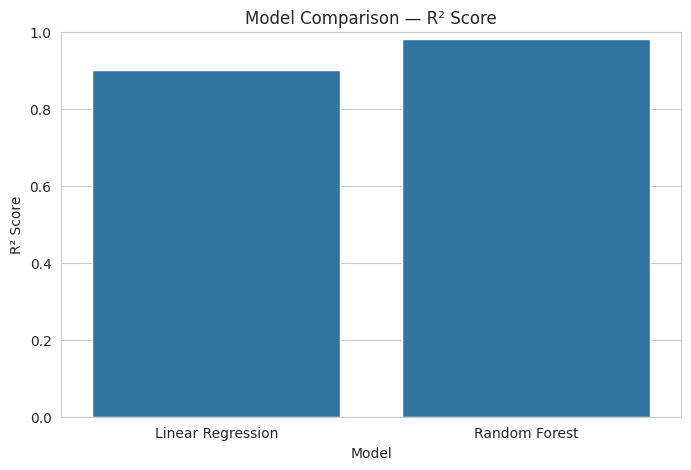

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison — R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0, 1)

plt.show()

#Actual VS Predicted Sales

In [ ]:
if r2_rf >= r2_linear:
    best_model_name = "Random Forest"
    best_predictions = y_pred_rf
    best_r2 = r2_rf
else:
    best_model_name = "Linear Regression"
    best_predictions = y_pred_linear
    best_r2 = r2_linear

print("Best Model:", best_model_name)
print(f"R² Score: {best_r2:.4f}")

Best Model: Random Forest
R² Score: 0.9818


##Actual VS Predicted

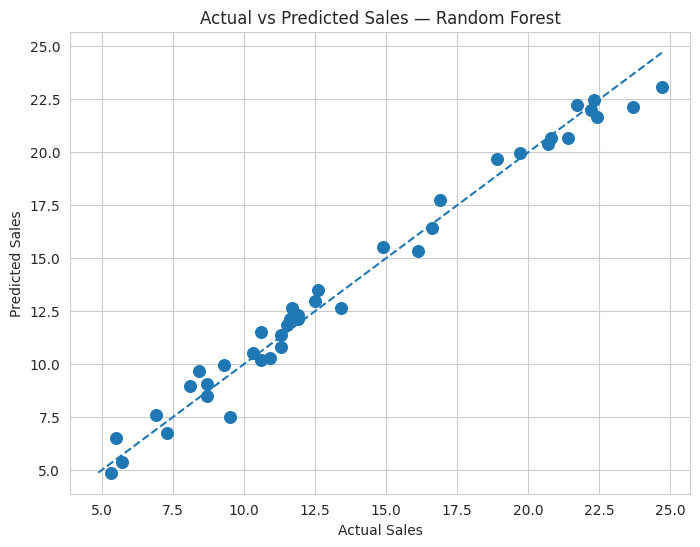

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    s=70
)

# Perfect prediction line
minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    f"Actual vs Predicted Sales — {best_model_name}"
)

plt.show()

#Residual Analysis

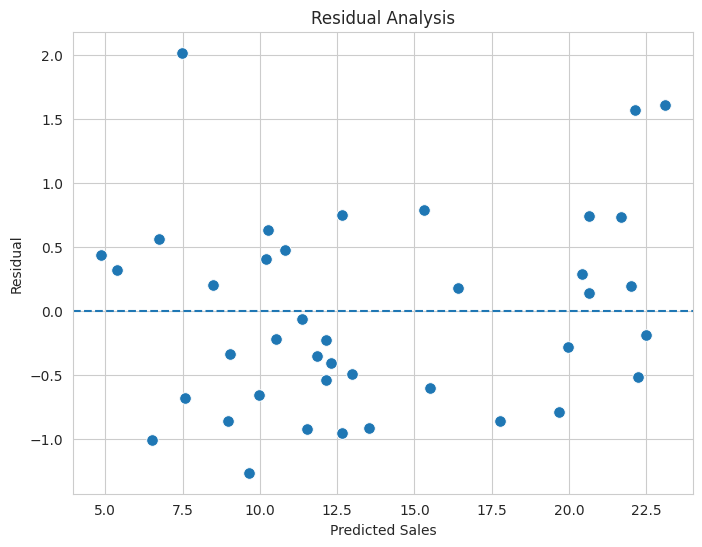

In [ ]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    s=70
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.show()

#Actual VS Predicted Table

In [ ]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

comparison["Difference"] = (
    comparison["Actual Sales"] -
    comparison["Predicted Sales"]
)

comparison.head(15)

,Actual Sales,Predicted Sales,Difference
0,16.9,17.7615,-0.8615
1,22.4,21.6665,0.7335
2,21.4,20.6595,0.7405
3,7.3,6.7395,0.5605
4,24.7,23.0960,1.6040
5,12.6,13.5155,-0.9155
6,22.3,22.4860,-0.1860
7,8.4,9.6625,-1.2625
8,11.5,11.8545,-0.3545
9,14.9,15.5040,-0.6040


##Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,tv,0.624727
1,radio,0.362119
2,newspaper,0.013153


##Feature Importance Graph

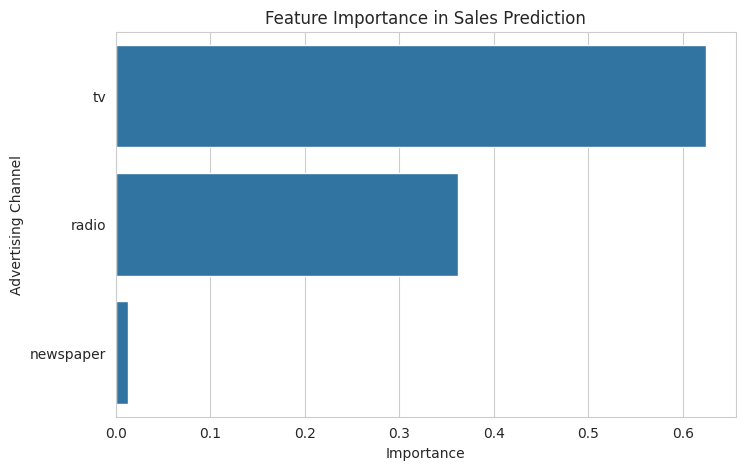

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Sales Prediction")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

##Advertising Insights

In [ ]:
print("========== ADVERTISING INSIGHTS ==========\n")

for feature in features:
    correlation = df[feature].corr(df["sales"])

    print(
        f"{feature.upper()} vs Sales Correlation: "
        f"{correlation:.4f}"
    )

print("\n==========================================")

========== ADVERTISING INSIGHTS ==========

TV vs Sales Correlation: 0.7822
RADIO vs Sales Correlation: 0.5762
NEWSPAPER vs Sales Correlation: 0.2283



##Final Model Summary

In [ ]:
print("========== FINAL MODEL SUMMARY ==========\n")

print("Total Records:", len(df))

print("Features Used:", features)

print("Models Compared:")
print("- Linear Regression")
print("- Random Forest Regressor")

print("\nBest Model:", best_model_name)

print(f"Best R² Score: {best_r2:.4f}")

print("\n=========================================")

========== FINAL MODEL SUMMARY ==========

Total Records: 200
Features Used: ['tv', 'radio', 'newspaper']
Models Compared:
- Linear Regression
- Random Forest Regressor

Best Model: Random Forest
Best R² Score: 0.9818



#Conclusion

In this project, a machine learning approach was used to predict sales
based on advertising expenditure.

The dataset was cleaned and explored using Python, Pandas, Matplotlib,
and Seaborn. Exploratory Data Analysis was performed to understand the
distribution of sales and the relationships between advertising
channels and sales.

Correlation analysis was used to investigate the relationship between
advertising expenditure and sales. Relevant advertising features were
then selected and used to train regression models.

Two machine learning models were evaluated:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Mean Squared
Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The model comparison helped identify the better-performing approach for
sales prediction. Actual-versus-predicted analysis and residual analysis
were also performed to assess prediction quality.

Overall, this project demonstrates how machine learning and data
analysis can be used to understand advertising effectiveness and
predict sales outcomes, supporting data-driven business decisions.